# Credit-Risk Early Signals from CFPB Consumer Complaints

## Project Overview
This project builds an early-warning machine learning pipeline to detect elevated credit-risk signals from CFPB consumer complaint narratives. The goal is not to predict confirmed fraud directly, but to identify complaints associated with risky downstream outcomes using proxy supervisory signals derived from complaint resolution fields.

## Business Objective
Financial institutions receive large volumes of consumer complaints, but only a small fraction may indicate meaningful operational, compliance, or credit-risk concerns. A model that flags high-risk complaint narratives can support:
- early triage and prioritization,
- faster manual review,
- downstream risk monitoring,
- and more interpretable complaint surveillance.

## Modeling Objective
Using complaint text, product metadata, company identity, and state-level information, the task is to predict a proxy risk label (`risk_flag`) built from post-complaint outcomes such as dispute and untimely response. Because the positive class is rare, the project emphasizes rare-event evaluation, threshold selection, interpretability, and deployment-oriented validation.

## What this notebook includes
This notebook covers:
1. data loading and sharding,
2. text preprocessing and proxy label construction,
3. temporal train/test splitting,
4. feature engineering with TF-IDF, metadata, and domain lexicons,
5. classical ML baselines and hybrid models,
6. embedding-based and fine-tuned transformer models,
7. model interpretability with coefficients and SHAP,
8. threshold optimization and cost-sensitive evaluation,
9. calibration analysis,
10. robustness checks including cross-product generalization.

## Final Takeaway
The strongest overall model in this workflow is an interpretable logistic regression model using lexicon and structured features, with LightGBM as a high-performance challenger. The overall pipeline is designed to demonstrate practical data science, applied NLP, and risk-modeling skills relevant to credit, fraud, and financial decision-support teams.

In [ ]:
import os
import gc
import re
import json
import math
import warnings
from pathlib import Path

import numpy as np
import pandas as pd

warnings.filterwarnings("ignore")


RANDOM_STATE = 42
N_SHARDS = 5
SHARD_ID = 0  # use one shard for manageable experimentation
CHUNKSIZE = 100_000

# Update these paths if needed
drive.mount('/content/drive')


DATA_PATH = Path("/content/drive/MyDrive/complaints.csv")

assert DATA_PATH.exists(), f"File not found: {DATA_PATH}"

SHARD_PATH = Path(f"/content/complaints_shard_{SHARD_ID}_of_{N_SHARDS}.csv")


CORE_COLUMNS = [
    "Date received",
    "Product",
    "Sub-product",
    "Issue",
    "Sub-issue",
    "Consumer complaint narrative",
    "Company public response",
    "Company",
    "State",
    "ZIP code",
    "Tags",
    "Consumer consent provided?",
    "Submitted via",
    "Date sent to company",
    "Company response to consumer",
    "Timely response?",
    "Consumer disputed?",
    "Complaint ID"
]

print("Configuration")
print(f"  DATA_PATH      : {DATA_PATH}")
print(f"  SHARD_ID       : {SHARD_ID}")
print(f"  N_SHARDS       : {N_SHARDS}")
print(f"  CHUNKSIZE      : {CHUNKSIZE}")
print(f"  SHARD_PATH     : {SHARD_PATH}")
print(f"  CORE_COLUMNS   : {len(CORE_COLUMNS)} columns")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Configuration
  DATA_PATH      : /content/drive/MyDrive/complaints.csv
  SHARD_ID       : 0
  N_SHARDS       : 5
  CHUNKSIZE      : 100000
  SHARD_PATH     : /content/complaints_shard_0_of_5.csv
  CORE_COLUMNS   : 18 columns


In [ ]:

# Create shard from the full CFPB CSV (only once)


if not os.path.exists(SHARD_PATH):
    print(f"Shard not found. Creating shard {SHARD_ID} out of {N_SHARDS}...")

    chunk_idx = 0
    rows_written = 0

    for chunk in pd.read_csv(DATA_PATH, usecols=CORE_COLUMNS, chunksize=CHUNKSIZE, low_memory=False):
        shard_chunk = chunk.iloc[chunk_idx % N_SHARDS :: N_SHARDS].copy()

        if len(shard_chunk) > 0:
            mode = "w" if rows_written == 0 else "a"
            header = rows_written == 0
            shard_chunk.to_csv(SHARD_PATH, mode=mode, header=header, index=False)
            rows_written += len(shard_chunk)

        chunk_idx += 1

    print(f"Shard creation complete. Rows written: {rows_written:,}")
else:
    print(f"Shard already exists: {SHARD_PATH}")

Shard already exists: /content/complaints_shard_0_of_5.csv


In [ ]:
df = pd.read_csv(SHARD_PATH, low_memory=False)

print("Shard loaded successfully.")
print(f"Shape: {df.shape[0]:,} rows x {df.shape[1]} columns")

display(df.head(3))

Shard loaded successfully.
Shape: 2,295,423 rows x 18 columns


,Date received,Product,Sub-product,Issue,Sub-issue,Consumer complaint narrative,Company public response,Company,State,ZIP code,Tags,Consumer consent provided?,Submitted via,Date sent to company,Company response to consumer,Timely response?,Consumer disputed?,Complaint ID
0,2020-07-06,"Credit reporting, credit repair services, or o...",Credit reporting,Incorrect information on your report,Information belongs to someone else,NaN,Company has responded to the consumer and the ...,Experian Information Solutions Inc.,FL,346XX,NaN,Other,Web,2020-07-06,Closed with explanation,Yes,NaN,3730948
1,2025-10-14,Credit reporting or other personal consumer re...,Credit reporting,Improper use of your report,Reporting company used your report improperly,NaN,NaN,"TRANSUNION INTERMEDIATE HOLDINGS, INC.",NC,27597,NaN,NaN,Web,2025-10-14,In progress,Yes,NaN,16561479
2,2025-10-14,Credit reporting or other personal consumer re...,Credit reporting,Incorrect information on your report,Account information incorrect,NaN,NaN,Experian Information Solutions Inc.,IL,60120,NaN,NaN,Web,2025-10-14,In progress,Yes,NaN,16582012


In [ ]:
print("Column names:")
print(list(df.columns))

print("\nMissing values (top 15 columns):")
display(df.isna().sum().sort_values(ascending=False).head(15).to_frame("missing_count"))

print("\nData types:")
display(df.dtypes.to_frame("dtype"))

Column names:
['Date received', 'Product', 'Sub-product', 'Issue', 'Sub-issue', 'Consumer complaint narrative', 'Company public response', 'Company', 'State', 'ZIP code', 'Tags', 'Consumer consent provided?', 'Submitted via', 'Date sent to company', 'Company response to consumer', 'Timely response?', 'Consumer disputed?', 'Complaint ID']

Missing values (top 15 columns):


,missing_count
Tags,2161622
Consumer disputed?,2141993
Consumer complaint narrative,1614302
Company public response,1138748
Consumer consent provided?,384693
Sub-issue,171492
Sub-product,46893
State,11323
ZIP code,6060
Company response to consumer,8



Data types:


,dtype
Date received,object
Product,object
Sub-product,object
Issue,object
Sub-issue,object
Consumer complaint narrative,object
Company public response,object
Company,object
State,object
ZIP code,object


## 2. Text preprocessing and proxy label construction

This section prepares the raw CFPB complaint shard for modeling.

The preprocessing pipeline includes:
- standardizing column names,
- parsing dates,
- cleaning and normalizing complaint narratives,
- removing rows without usable text,
- constructing a proxy risk target (`risk_flag`),
- and creating early domain features such as sentiment and urgency/dispute indicators.

### Proxy target definition
The target in this project is a **proxy risk label**, not a direct fraud outcome. A complaint is labeled as `risk_flag = 1` if it is associated with at least one downstream risk-related signal, such as:
- the consumer disputed the company response, or
- the company response was marked untimely.

This framing is useful for early-warning complaint triage in risk-monitoring settings.

### Why this matters
Consumer complaint text is noisy, inconsistent, and highly imbalanced. Careful preprocessing is essential before building rare-event models for risk detection.

In [ ]:
import unicodedata
from collections import Counter


def to_snake_case(col_name: str) -> str:
    col_name = str(col_name).strip().lower()
    col_name = re.sub(r"[^a-z0-9]+", "_", col_name)
    col_name = re.sub(r"_+", "_", col_name).strip("_")
    return col_name

df.columns = [to_snake_case(c) for c in df.columns]

print("Normalized columns:")
print(df.columns.tolist())


date_cols = ["date_received", "date_sent_to_company"]
for c in date_cols:
    if c in df.columns:
        df[c] = pd.to_datetime(df[c], errors="coerce")

print("\nDate parsing complete.")
for c in date_cols:
    if c in df.columns:
        print(f"{c}: {df[c].min()} -> {df[c].max()}")

Normalized columns:
['date_received', 'product', 'sub_product', 'issue', 'sub_issue', 'consumer_complaint_narrative', 'company_public_response', 'company', 'state', 'zip_code', 'tags', 'consumer_consent_provided', 'submitted_via', 'date_sent_to_company', 'company_response_to_consumer', 'timely_response', 'consumer_disputed', 'complaint_id']

Date parsing complete.
date_received: 2011-12-01 00:00:00 -> 2025-10-15 00:00:00
date_sent_to_company: 2011-12-01 00:00:00 -> 2025-10-15 00:00:00


In [ ]:


import nltk

nltk.download("stopwords")
nltk.download("wordnet")
nltk.download("omw-1.4")
nltk.download("vader_lexicon")

from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.sentiment import SentimentIntensityAnalyzer

lemmatizer = WordNetLemmatizer()
sia = SentimentIntensityAnalyzer()

BASE_STOPWORDS = set(stopwords.words("english"))

# Domain-specific stopwords that may not help modeling
DOMAIN_STOPWORDS = {
    "xxxx", "xx", "consumer", "complaint", "company", "account", "creditor"
}

STOPWORDS = BASE_STOPWORDS.union(DOMAIN_STOPWORDS)

TEXT_COL = "consumer_complaint_narrative"

def normalize_unicode(text: str) -> str:
    return unicodedata.normalize("NFKD", text)

def basic_text_clean(text: str) -> str:
    if pd.isna(text):
        return ""

    text = str(text)
    text = normalize_unicode(text)
    text = text.lower()


    text = re.sub(r"x{2,}", " ", text)

    text = re.sub(r"http\S+|www\.\S+", " ", text)
    text = re.sub(r"\S+@\S+", " ", text)

    text = re.sub(r"[^a-z\s]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

def lemmatize_and_filter(text: str, remove_stopwords: bool = True) -> str:
    if not text:
        return ""
    tokens = text.split()
    cleaned_tokens = []
    for tok in tokens:
        if remove_stopwords and tok in STOPWORDS:
            continue
        lemma = lemmatizer.lemmatize(tok)
        if len(lemma) >= 2:
            cleaned_tokens.append(lemma)
    return " ".join(cleaned_tokens)

def full_clean_text(text: str) -> str:
    text = basic_text_clean(text)
    text = lemmatize_and_filter(text, remove_stopwords=True)
    return text

print("Text cleaning helpers ready.")

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!
[nltk_data] Downloading package vader_lexicon to /root/nltk_data...


Text cleaning helpers ready.


In [ ]:


if TEXT_COL not in df.columns:
    raise ValueError(f"Expected text column '{TEXT_COL}' not found.")

# Keep original raw text for reference
df["narrative_raw"] = df[TEXT_COL].fillna("").astype(str)

# Cleaned text for modeling
df["narrative_clean"] = df["narrative_raw"].apply(full_clean_text)

# Text length diagnostics
df["raw_char_len"] = df["narrative_raw"].str.len()
df["clean_word_count"] = df["narrative_clean"].str.split().apply(len)

print("Text cleaning complete.")
print(df[["narrative_raw", "narrative_clean", "raw_char_len", "clean_word_count"]].head(3))

Text cleaning complete.
  narrative_raw narrative_clean  raw_char_len  clean_word_count
0                                           0                 0
1                                           0                 0
2                                           0                 0


In [ ]:
def normalize_binary_text(val):
    if pd.isna(val):
        return ""
    return str(val).strip().lower()

if "consumer_disputed" in df.columns:
    df["consumer_disputed_norm"] = df["consumer_disputed"].apply(normalize_binary_text)
else:
    df["consumer_disputed_norm"] = ""

if "timely_response" in df.columns:
    df["timely_response_norm"] = df["timely_response"].apply(normalize_binary_text)
else:
    df["timely_response_norm"] = ""

df["is_disputed"] = df["consumer_disputed_norm"].isin(["yes", "y", "true", "1"]).astype(int)
df["is_untimely"] = (~df["timely_response_norm"].isin(["yes", "y", "true", "1"])).astype(int)

# Proxy target
df["risk_flag"] = ((df["is_disputed"] == 1) | (df["is_untimely"] == 1)).astype(int)

print("Proxy label construction complete.")
print(df[["consumer_disputed", "timely_response", "is_disputed", "is_untimely", "risk_flag"]].head(10))

print("\nTarget distribution:")
display(df["risk_flag"].value_counts(dropna=False).to_frame("count"))
print(f"Positive rate: {df['risk_flag'].mean():.4%}")

Proxy label construction complete.
  consumer_disputed timely_response  is_disputed  is_untimely  risk_flag
0               NaN             Yes            0            0          0
1               NaN             Yes            0            0          0
2               NaN             Yes            0            0          0
3               NaN             Yes            0            0          0
4               NaN             Yes            0            0          0
5               NaN             Yes            0            0          0
6               NaN             Yes            0            0          0
7               NaN             Yes            0            0          0
8               NaN             Yes            0            0          0
9               NaN             Yes            0            0          0

Target distribution:


,count
risk_flag,
0,2250119
1,45304


Positive rate: 1.9737%


In [ ]:
URGENCY_TERMS = [
    "urgent", "immediately", "asap", "emergency", "critical",
    "serious", "right away", "cannot wait", "help", "desperate"
]

DISPUTE_TERMS = [
    "dispute", "fraud", "identity theft", "unauthorized", "not mine",
    "wrong balance", "incorrect", "charged twice", "late fee",
    "credit report", "collection", "closed account", "did not authorize"
]

def count_phrase_matches(text: str, phrase_list) -> int:
    if not text:
        return 0
    count = 0
    for phrase in phrase_list:
        if phrase in text:
            count += 1
    return count

df["urgency_count"] = df["narrative_clean"].apply(lambda x: count_phrase_matches(x, URGENCY_TERMS))
df["has_urgency_word"] = (df["urgency_count"] > 0).astype(int)

df["dispute_keyword_count"] = df["narrative_clean"].apply(lambda x: count_phrase_matches(x, DISPUTE_TERMS))
df["has_dispute_keyword"] = (df["dispute_keyword_count"] > 0).astype(int)

print("Domain keyword features added.")
display(
    df[["narrative_clean", "urgency_count", "has_urgency_word", "dispute_keyword_count", "has_dispute_keyword"]]
    .head(5)
)

Domain keyword features added.


,narrative_clean,urgency_count,has_urgency_word,dispute_keyword_count,has_dispute_keyword
0,,0,0,0,0
1,,0,0,0,0
2,,0,0,0,0
3,,0,0,0,0
4,,0,0,0,0


In [ ]:
def get_vader_scores(text: str):
    if not text:
        return {"neg": 0.0, "neu": 0.0, "pos": 0.0, "compound": 0.0}
    return sia.polarity_scores(text)

sentiment_scores = df["narrative_raw"].fillna("").astype(str).apply(get_vader_scores)

df["sent_neg"] = sentiment_scores.apply(lambda x: x["neg"])
df["sent_neu"] = sentiment_scores.apply(lambda x: x["neu"])
df["sent_pos"] = sentiment_scores.apply(lambda x: x["pos"])
df["sent_compound"] = sentiment_scores.apply(lambda x: x["compound"])

print("Sentiment features added.")
display(df[["narrative_raw", "sent_neg", "sent_neu", "sent_pos", "sent_compound"]].head(3))

Sentiment features added.


,narrative_raw,sent_neg,sent_neu,sent_pos,sent_compound
0,,0.0,0.0,0.0,0.0
1,,0.0,0.0,0.0,0.0
2,,0.0,0.0,0.0,0.0


In [ ]:
required_cols = [
    "date_received",
    "product",
    "company",
    "state",
    "narrative_clean",
    "risk_flag"
]

available_required_cols = [c for c in required_cols if c in df.columns]
print("Required columns available:", available_required_cols)

model_df = df.copy()

# Keep rows with usable text and valid date
model_df = model_df[model_df["date_received"].notna()].copy()
model_df = model_df[model_df["narrative_clean"].str.len() > 0].copy()
model_df = model_df[model_df["clean_word_count"] >= 3].copy()

# Fill structured fields
for c in ["product", "company", "state"]:
    if c in model_df.columns:
        model_df[c] = model_df[c].fillna("UNKNOWN").astype(str).str.strip()

model_df.reset_index(drop=True, inplace=True)

print("Modeling dataframe ready.")
print(f"Shape: {model_df.shape[0]:,} rows x {model_df.shape[1]} columns")
print(f"Positive rate: {model_df['risk_flag'].mean():.4%}")

display(
    model_df[
        ["date_received", "product", "company", "state", "narrative_clean", "risk_flag"]
    ].head(5)
)

Required columns available: ['date_received', 'product', 'company', 'state', 'narrative_clean', 'risk_flag']
Modeling dataframe ready.
Shape: 679,808 rows x 35 columns
Positive rate: 2.0734%


,date_received,product,company,state,narrative_clean,risk_flag
0,2025-09-22,Credit card,U.S. BANCORP,DE,year took thought legitimate taxi short distan...,0
1,2025-09-03,Credit card,FIRST PORTFOLIO SERVICING INC,KY,opened revvi card effort build credit paid ini...,0
2,2025-02-14,Credit reporting or other personal consumer re...,"Lockhart, Morris & Montgomery Inc.",FL,collection reported agency lockhart morris mon...,0
3,2025-08-08,Credit reporting or other personal consumer re...,"EQUIFAX, INC.",UNKNOWN,writing formally submit regarding handling ina...,0
4,2025-08-13,Credit reporting or other personal consumer re...,"TRANSUNION INTERMEDIATE HOLDINGS, INC.",NY,extremely dissatisfied failure comply section ...,0


In [ ]:
summary = pd.DataFrame({
    "metric": [
        "rows_after_filtering",
        "positive_rate",
        "avg_raw_char_len",
        "avg_clean_word_count",
        "num_products",
        "num_companies",
        "num_states"
    ],
    "value": [
        len(model_df),
        model_df["risk_flag"].mean(),
        model_df["raw_char_len"].mean(),
        model_df["clean_word_count"].mean(),
        model_df["product"].nunique() if "product" in model_df.columns else np.nan,
        model_df["company"].nunique() if "company" in model_df.columns else np.nan,
        model_df["state"].nunique() if "state" in model_df.columns else np.nan,
    ]
})

display(summary)

print("\nTop products by volume:")
if "product" in model_df.columns:
    display(model_df["product"].value_counts().head(10).to_frame("count"))

print("\nTop companies by volume:")
if "company" in model_df.columns:
    display(model_df["company"].value_counts().head(10).to_frame("count"))

,metric,value
0,rows_after_filtering,679808.000000
1,positive_rate,0.020734
2,avg_raw_char_len,1003.427228
3,avg_clean_word_count,74.462747
4,num_products,21.000000
5,num_companies,4336.000000
6,num_states,62.000000



Top products by volume:


,count
product,
Credit reporting or other personal consumer reports,286756
"Credit reporting, credit repair services, or other personal consumer reports",160385
Debt collection,74099
Checking or savings account,30841
Mortgage,26689
Credit card or prepaid card,21785
"Money transfer, virtual currency, or money service",20580
Credit card,18889
Student loan,11366



Top companies by volume:


,count
company,
"EQUIFAX, INC.",145214
"TRANSUNION INTERMEDIATE HOLDINGS, INC.",138861
Experian Information Solutions Inc.,133472
CAPITAL ONE FINANCIAL CORPORATION,12264
JPMORGAN CHASE & CO.,11425
WELLS FARGO & COMPANY,10889
"BANK OF AMERICA, NATIONAL ASSOCIATION",10339
"CITIBANK, N.A.",9993
"Block, Inc.",8263


## 3. Temporal train/test split and exploratory analysis

Because complaint data evolves over time, evaluating models with a random split can lead to overly optimistic performance estimates. Instead, this project uses a **temporal split** that mimics real-world deployment.

### Temporal validation strategy
The dataset is divided using a cutoff date:

- **Training set:** complaints received before the cutoff  
- **Test set:** complaints received on or after the cutoff  

This ensures that models are evaluated on **future complaints**, preventing leakage from future information.

### Why this matters for risk modeling
In financial applications such as credit risk or fraud detection, models are deployed to score **future events**, not randomly sampled historical observations. Temporal validation better reflects how models behave in production.

### Rare-event modeling
The target variable `risk_flag` is highly imbalanced. Therefore, evaluation focuses on:

- **PR-AUC** (precision–recall AUC)
- **threshold optimization**
- **recall-oriented metrics**

rather than relying solely on ROC-AUC.

### Exploratory goals
This section examines:

- class imbalance
- complaint volume over time
- risk rate over time
- distribution across products and companies

In [ ]:
SPLIT_DATE = pd.Timestamp("2025-07-01")

train_df = model_df[model_df["date_received"] < SPLIT_DATE].copy()
test_df  = model_df[model_df["date_received"] >= SPLIT_DATE].copy()

print("Temporal split complete")
print(f"Train rows: {len(train_df):,}")
print(f"Test rows : {len(test_df):,}")

print("\nTarget distribution:")
print("Train positive rate:", train_df["risk_flag"].mean())
print("Test positive rate :", test_df["risk_flag"].mean())

Temporal split complete
Train rows: 639,149
Test rows : 40,659

Target distribution:
Train positive rate: 0.021603726204687795
Test positive rate : 0.007058707789173369


In [ ]:
pos = train_df["risk_flag"].sum()
neg = len(train_df) - pos

print("Training class distribution")
print(f"Positive (risk_flag=1): {pos:,}")
print(f"Negative (risk_flag=0): {neg:,}")

imbalance_ratio = neg / max(pos, 1)
print(f"Imbalance ratio (neg/pos): {imbalance_ratio:.2f}")

SCALE_POS_WEIGHT = imbalance_ratio #used later for scale_pos_weight in LightGBM

Training class distribution
Positive (risk_flag=1): 13,808
Negative (risk_flag=0): 625,341
Imbalance ratio (neg/pos): 45.29


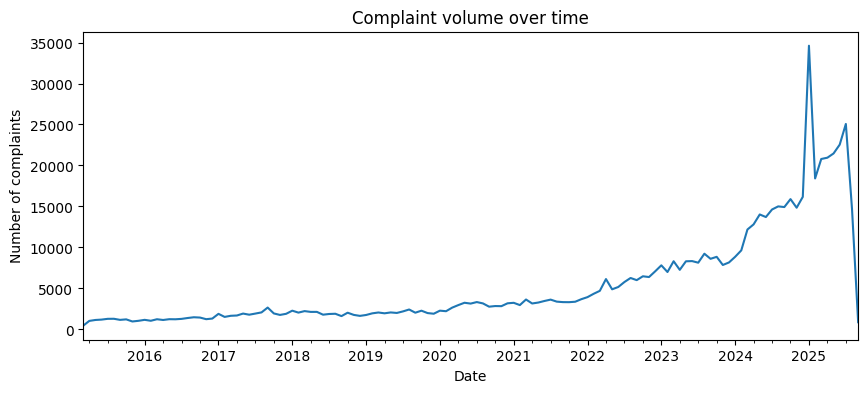

In [ ]:
import matplotlib.pyplot as plt

monthly_counts = (
    model_df
    .set_index("date_received")
    .resample("M")
    .size()
)

plt.figure(figsize=(10,4))
monthly_counts.plot()
plt.title("Complaint volume over time")
plt.xlabel("Date")
plt.ylabel("Number of complaints")
plt.show()

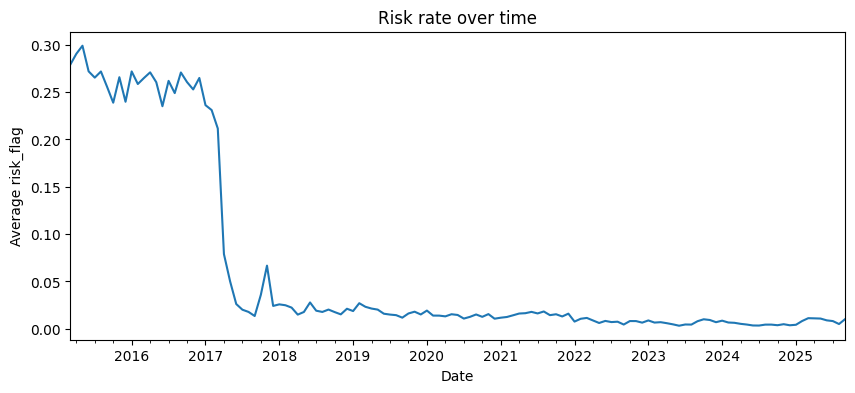

In [ ]:
monthly_risk = (
    model_df
    .set_index("date_received")
    .resample("M")["risk_flag"]
    .mean()
)

plt.figure(figsize=(10,4))
monthly_risk.plot()
plt.title("Risk rate over time")
plt.xlabel("Date")
plt.ylabel("Average risk_flag")
plt.show()

In [ ]:
product_risk = (
    train_df
    .groupby("product")["risk_flag"]
    .agg(["count","mean"])
    .sort_values("count", ascending=False)
)

display(product_risk.head(10))

,count,mean
product,,
Credit reporting or other personal consumer reports,254438,0.001890
"Credit reporting, credit repair services, or other personal consumer reports",160385,0.005262
Debt collection,70825,0.059146
Checking or savings account,29306,0.009896
Mortgage,26219,0.081353
Credit card or prepaid card,21785,0.011659
"Money transfer, virtual currency, or money service",19988,0.012908
Credit card,17482,0.051138
Student loan,11130,0.103774


In [ ]:
company_risk = (
    train_df
    .groupby("company")["risk_flag"]
    .agg(["count","mean"])
    .sort_values("count", ascending=False)
)

display(company_risk.head(10))

,count,mean
company,,
"EQUIFAX, INC.",134250,0.006108
"TRANSUNION INTERMEDIATE HOLDINGS, INC.",127771,0.002708
Experian Information Solutions Inc.,124424,0.002299
CAPITAL ONE FINANCIAL CORPORATION,11905,0.011172
JPMORGAN CHASE & CO.,11068,0.028912
WELLS FARGO & COMPANY,10413,0.055027
"BANK OF AMERICA, NATIONAL ASSOCIATION",10008,0.061451
"CITIBANK, N.A.",9545,0.028182
"Block, Inc.",7976,0.008526


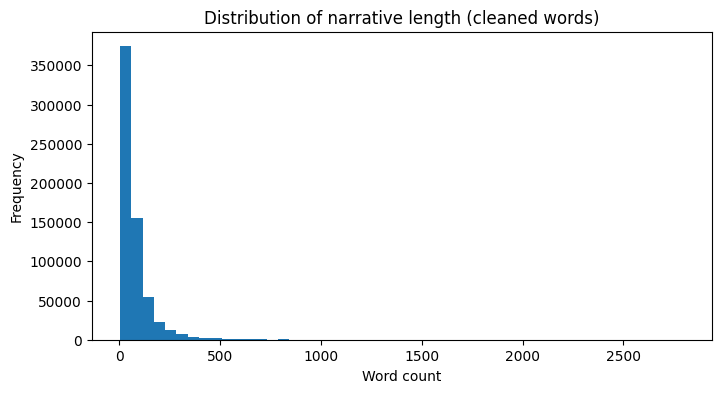

In [ ]:
plt.figure(figsize=(8,4))
plt.hist(train_df["clean_word_count"], bins=50)
plt.title("Distribution of narrative length (cleaned words)")
plt.xlabel("Word count")
plt.ylabel("Frequency")
plt.show()

In [ ]:
time_splits = [
    ("2024-12-31"),
    ("2025-03-31"),
    ("2025-06-30"),
]

rolling_sets = []

for cutoff in time_splits:
    cutoff = pd.Timestamp(cutoff)

    train_temp = model_df[model_df["date_received"] < cutoff]
    test_temp  = model_df[model_df["date_received"] >= cutoff]

    if len(test_temp) > 0:
        rolling_sets.append((cutoff, train_temp, test_temp))

print("Rolling validation windows created:")
for cutoff, tr, te in rolling_sets:
    print(f"Cutoff {cutoff.date()} -> train={len(tr):,}, test={len(te):,}")

Rolling validation windows created:
Cutoff 2024-12-31 -> train=499,934, test=179,874
Cutoff 2025-03-31 -> train=573,378, test=106,430
Cutoff 2025-06-30 -> train=638,392, test=41,416


## 4. Feature engineering

This section converts the cleaned complaint data into machine learning features.

The project combines **multiple feature families** to capture different types of signals:

### 1. Text features
The complaint narratives are transformed using **TF-IDF vectorization**.  
This captures important words and phrases that indicate potential risk signals in consumer complaints.

Example patterns:
- dispute language
- identity theft / unauthorized activity
- account closure or incorrect balances

### 2. Structured metadata
Additional context is captured through structured variables:

- product
- company
- state

These are encoded using **one-hot encoding**.

### 3. Domain features
Additional handcrafted signals include:

- sentiment scores from the complaint narrative
- urgency indicators
- dispute keyword counts

These features help capture domain knowledge about complaint severity.

### Final feature matrix
The final model input combines:

- TF-IDF text features
- structured metadata
- domain features

This hybrid approach balances **predictive performance and interpretability**, which is important for risk modeling applications.

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer

MAX_FEATURES = 20000

tfidf = TfidfVectorizer(
    max_features=MAX_FEATURES,
    ngram_range=(1,2),
    min_df=5,
    max_df=0.9
)

X_train_text = tfidf.fit_transform(train_df["narrative_clean"])
X_test_text  = tfidf.transform(test_df["narrative_clean"])

print("TF-IDF features created")
print("Train text shape:", X_train_text.shape)
print("Test text shape :", X_test_text.shape)

TF-IDF features created
Train text shape: (639149, 20000)
Test text shape : (40659, 20000)


In [ ]:
from sklearn.preprocessing import OneHotEncoder

STRUCT_COLS = ["product","company","state"]

encoder = OneHotEncoder(
    handle_unknown="ignore",
    sparse_output=True # Changed 'sparse' to 'sparse_output'
)

X_train_struct = encoder.fit_transform(train_df[STRUCT_COLS])
X_test_struct  = encoder.transform(test_df[STRUCT_COLS])

print("Structured features created")
print("Train struct shape:", X_train_struct.shape)
print("Test struct shape :", X_test_struct.shape)

Structured features created
Train struct shape: (639149, 4373)
Test struct shape : (40659, 4373)


In [ ]:
NUMERIC_FEATURES = [
    "sent_neg",
    "sent_neu",
    "sent_pos",
    "sent_compound",
    "urgency_count",
    "has_urgency_word",
    "dispute_keyword_count",
    "has_dispute_keyword",
    "clean_word_count"
]

X_train_numeric = train_df[NUMERIC_FEATURES].values
X_test_numeric  = test_df[NUMERIC_FEATURES].values

print("Numeric feature matrix created")
print("Train numeric shape:", X_train_numeric.shape)
print("Test numeric shape :", X_test_numeric.shape)

Numeric feature matrix created
Train numeric shape: (639149, 9)
Test numeric shape : (40659, 9)


In [ ]:
from scipy.sparse import hstack
from scipy.sparse import csr_matrix

X_train = hstack([
    X_train_text,
    X_train_struct,
    csr_matrix(X_train_numeric)
])

X_test = hstack([
    X_test_text,
    X_test_struct,
    csr_matrix(X_test_numeric)
])

y_train = train_df["risk_flag"].values
y_test  = test_df["risk_flag"].values

print("Final feature matrix")
print("X_train shape:", X_train.shape)
print("X_test shape :", X_test.shape)

Final feature matrix
X_train shape: (639149, 24382)
X_test shape : (40659, 24382)


In [ ]:
feature_summary = pd.DataFrame({
    "feature_group": [
        "TF-IDF text",
        "Structured metadata",
        "Numeric/domain features"
    ],
    "dimension": [
        X_train_text.shape[1],
        X_train_struct.shape[1],
        X_train_numeric.shape[1]
    ]
})

display(feature_summary)

,feature_group,dimension
0,TF-IDF text,20000
1,Structured metadata,4373
2,Numeric/domain features,9


## 5. Baseline models and rare-event evaluation

This section trains baseline machine learning models for the complaint risk prediction task.

Two model families are used:

### Logistic Regression
Logistic regression is widely used in financial modeling because it provides:

- strong performance with sparse features
- interpretability through coefficients
- straightforward probability outputs

### LightGBM
LightGBM is used as a nonlinear challenger model. Tree-based models can capture:

- nonlinear interactions
- feature combinations
- complex patterns in high-dimensional data

### Class imbalance handling
The target variable is highly imbalanced, so models use class weighting or `scale_pos_weight` to correct for the rare positive class.

### Evaluation metrics
Because this is a rare-event problem, we emphasize:

- **PR-AUC (Precision–Recall AUC)**
- **F2 score**
- **threshold optimization**
- **cost-based evaluation**

rather than relying only on ROC-AUC.

### Probability calibration
For deployment in risk monitoring systems, probability estimates must be reliable. Therefore this section also evaluates:

- Brier score
- reliability curves
- calibrated probability models

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, average_precision_score
from sklearn.metrics import precision_recall_curve
import lightgbm as lgb

# Class imbalance weight
pos = y_train.sum()
neg = len(y_train) - pos
scale_pos_weight = neg / pos

print("Class imbalance ratio:", scale_pos_weight)

# Logistic Regression
log_model = LogisticRegression(
    max_iter=200,
    class_weight="balanced",
    n_jobs=-1
)

log_model.fit(X_train, y_train)

# LightGBM
lgb_model = lgb.LGBMClassifier(
    n_estimators=200,
    learning_rate=0.05,
    scale_pos_weight=scale_pos_weight,
    random_state=42
)

lgb_model.fit(X_train, y_train)

# Predictions
log_probs = log_model.predict_proba(X_test)[:,1]
lgb_probs = lgb_model.predict_proba(X_test)[:,1]

print("LogReg AUROC:", roc_auc_score(y_test, log_probs))
print("LightGBM AUROC:", roc_auc_score(y_test, lgb_probs))

print("LogReg PR-AUC:", average_precision_score(y_test, log_probs))
print("LightGBM PR-AUC:", average_precision_score(y_test, lgb_probs))

Class imbalance ratio: 45.2883111239861
[LightGBM] [Info] Number of positive: 13808, number of negative: 625341
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 49.655007 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1986278
[LightGBM] [Info] Number of data points in the train set: 639149, number of used features: 20954
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.021604 -> initscore=-3.813049
[LightGBM] [Info] Start training from score -3.813049
LogReg AUROC: 0.9554907651523755
LightGBM AUROC: 0.9661623814897757
LogReg PR-AUC: 0.28620840684319054
LightGBM PR-AUC: 0.31376137661635867


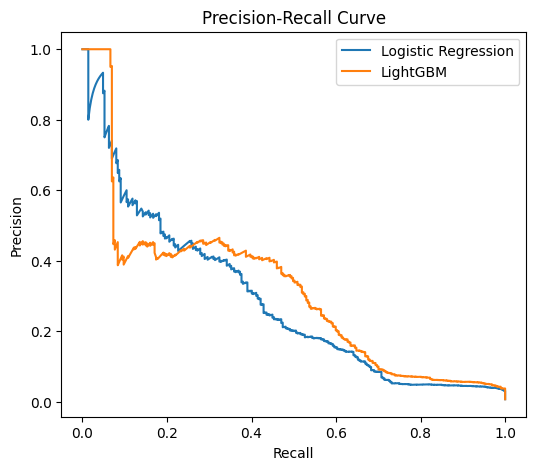

In [ ]:
import matplotlib.pyplot as plt

precision_log, recall_log, _ = precision_recall_curve(y_test, log_probs)
precision_lgb, recall_lgb, _ = precision_recall_curve(y_test, lgb_probs)

plt.figure(figsize=(6,5))
plt.plot(recall_log, precision_log, label="Logistic Regression")
plt.plot(recall_lgb, precision_lgb, label="LightGBM")

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.legend()
plt.show()

In [ ]:
import numpy as np
from sklearn.metrics import fbeta_score

thresholds = np.linspace(0.01,0.99,100)

best_thresh = 0
best_f2 = 0

for t in thresholds:

    preds = (log_probs >= t).astype(int)

    score = fbeta_score(y_test, preds, beta=2)

    if score > best_f2:
        best_f2 = score
        best_thresh = t

print("Best threshold (F2):", best_thresh)
print("Best F2 score:", best_f2)

Best threshold (F2): 0.8019191919191919
Best F2 score: 0.390290337934317


In [ ]:
#example cost based evaluation

FP_COST = 10
FN_COST = 1000

def expected_cost(y_true, y_prob, threshold):

    preds = (y_prob >= threshold).astype(int)

    fp = ((preds==1) & (y_true==0)).sum()
    fn = ((preds==0) & (y_true==1)).sum()

    cost = fp*FP_COST + fn*FN_COST

    return cost

costs = []

for t in thresholds:
    c = expected_cost(y_test, log_probs, t)
    costs.append(c)

best_cost_threshold = thresholds[np.argmin(costs)]

print("Best threshold by cost:", best_cost_threshold)
print("Minimum expected cost:", min(costs))

Best threshold by cost: 0.3465656565656566
Minimum expected cost: 75080


In [ ]:
from sklearn.metrics import brier_score_loss

brier = brier_score_loss(y_test, log_probs)

print("Brier score:", brier)

Brier score: 0.06815112084592126


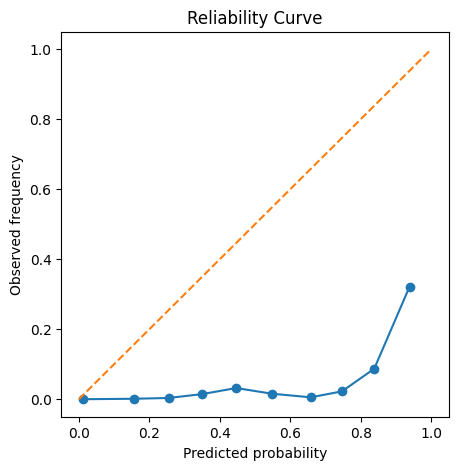

In [ ]:
from sklearn.calibration import calibration_curve

prob_true, prob_pred = calibration_curve(y_test, log_probs, n_bins=10)

plt.figure(figsize=(5,5))

plt.plot(prob_pred, prob_true, marker='o')
plt.plot([0,1],[0,1], linestyle="--")

plt.xlabel("Predicted probability")
plt.ylabel("Observed frequency")
plt.title("Reliability Curve")

plt.show()

In [ ]:
from sklearn.calibration import CalibratedClassifierCV

cal_model = CalibratedClassifierCV(
    log_model,
    method="isotonic",
    cv=3
)

cal_model.fit(X_train, y_train)

cal_probs = cal_model.predict_proba(X_test)[:,1]

print("Brier before:", brier_score_loss(y_test, log_probs))
print("Brier after :", brier_score_loss(y_test, cal_probs))

Brier before: 0.06815112084592126
Brier after : 0.006271101669283462


## 6. Model interpretability and feature importance

In financial risk modeling, interpretability is critical.  
Stakeholders must understand why a model flags certain cases as risky.

This section analyzes model behavior using three approaches:

### Logistic Regression Coefficients
Logistic regression provides direct interpretability through model coefficients.  
Positive coefficients increase predicted risk, while negative coefficients decrease risk.

### Tree-based Feature Importance
LightGBM feature importance highlights which variables contribute most to model decisions.

### SHAP Analysis
SHAP (SHapley Additive exPlanations) provides a unified framework for explaining model predictions.  
It quantifies the contribution of each feature to individual predictions.

Interpretability is essential for:

- regulatory compliance
- model validation
- stakeholder trust
- diagnosing model bias

In [ ]:
import pandas as pd
import numpy as np

# Extract feature names
tfidf_features = tfidf.get_feature_names_out()
struct_features = encoder.get_feature_names_out(STRUCT_COLS)
numeric_features = NUMERIC_FEATURES

feature_names = list(tfidf_features) + list(struct_features) + list(numeric_features)

# Logistic coefficients
coefficients = log_model.coef_[0]

coef_df = pd.DataFrame({
    "feature": feature_names,
    "coefficient": coefficients
})

coef_df["abs_coef"] = coef_df["coefficient"].abs()

print("Top positive risk predictors")
display(coef_df.sort_values("coefficient", ascending=False).head(20))

print("Top negative predictors")
display(coef_df.sort_values("coefficient").head(20))

Top positive risk predictors


,feature,coefficient,abs_coef
20005,product_Credit reporting,5.388921,5.388921
23596,company_Servicer under contract with Federal S...,2.414365,2.414365
20002,product_Consumer Loan,2.062351,2.062351
20000,product_Bank account or service,2.049735,2.049735
20729,"company_CCS Financial Services, Inc.",1.895601,1.895601
23253,company_ROBINHOOD MARKETS INC.,1.802820,1.802820
22468,company_MOHELA,1.652297,1.652297
21425,company_EdFinancial Services,1.645828,1.645828
21065,company_Conduent Incorporated,1.325246,1.325246
22649,"company_Mobiloans, LLC",0.955004,0.955004


Top negative predictors


,feature,coefficient,abs_coef
21483,company_Experian Information Solutions Inc.,-5.441761,5.441761
23833,"company_TRANSUNION INTERMEDIATE HOLDINGS, INC.",-5.086457,5.086457
21385,"company_EQUIFAX, INC.",-3.233441,3.233441
20019,product_Vehicle loan or lease,-1.951358,1.951358
20001,product_Checking or savings account,-1.933026,1.933026
23360,company_Resurgent Capital Services L.P.,-1.813014,1.813014
20701,company_CAPITAL ONE FINANCIAL CORPORATION,-1.794861,1.794861
20004,product_Credit card or prepaid card,-1.791257,1.791257
20645,"company_Bread Financial Holdings, Inc.",-1.624581,1.624581
20006,product_Credit reporting or other personal con...,-1.597449,1.597449


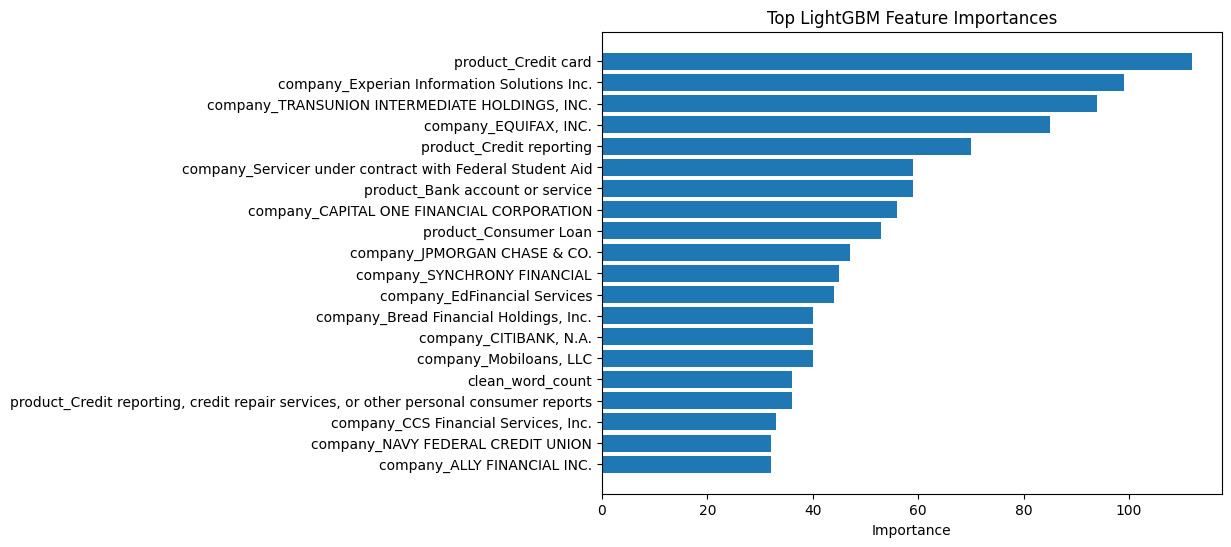

In [ ]:
import matplotlib.pyplot as plt

importance = lgb_model.feature_importances_

importance_df = pd.DataFrame({
    "feature": feature_names,
    "importance": importance
})

importance_df = importance_df.sort_values("importance", ascending=False)

plt.figure(figsize=(8,6))

top_features = importance_df.head(20)

plt.barh(top_features["feature"][::-1], top_features["importance"][::-1])

plt.title("Top LightGBM Feature Importances")
plt.xlabel("Importance")

plt.show()

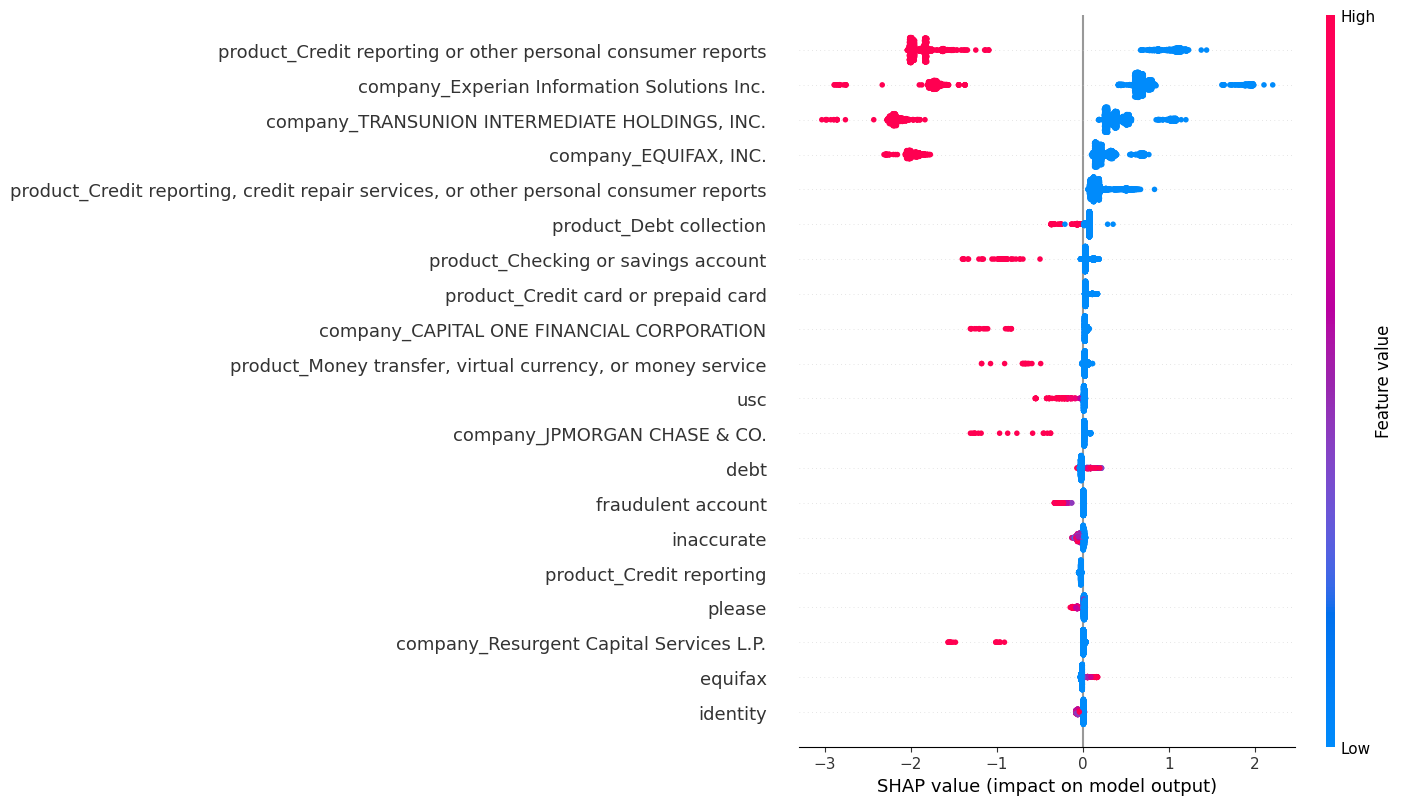

In [ ]:
#SHAP
import shap

# Use small sample for efficiency
sample_idx = np.random.choice(X_test.shape[0], 2000, replace=False)

X_sample = X_test[sample_idx]
X_sample_dense = X_sample.toarray() # Convert sparse matrix to dense

explainer = shap.TreeExplainer(lgb_model)

shap_values = explainer.shap_values(X_sample)

# For binary classification, shap_values returns a list of two arrays. We need to select one.
# Assuming the positive class is at index 1.
shap_values_for_plot = shap_values[1].toarray() if isinstance(shap_values, list) else shap_values.toarray()

shap.summary_plot(
    shap_values_for_plot, # Pass the dense array of shap_values
    X_sample_dense, # Pass the dense array of features
    feature_names=feature_names,
    max_display=20
)

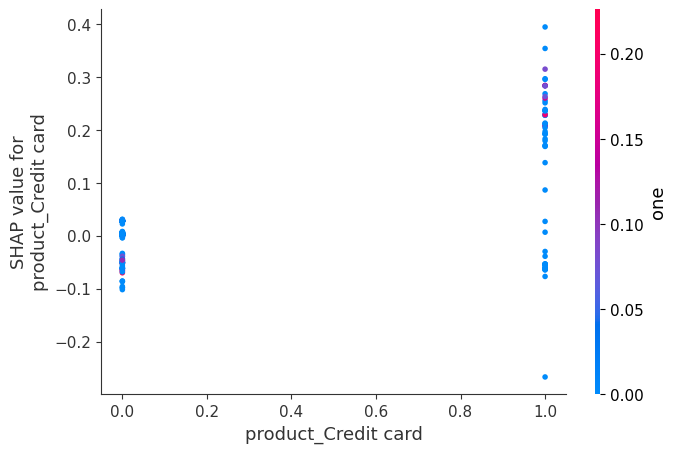

In [ ]:
top_feature = importance_df.iloc[0]["feature"]

feature_index = feature_names.index(top_feature)

# Ensure X_sample_dense and shap_values_for_plot are available or redefine them if this cell is run independently
# For robustness, we can re-create them here if needed, assuming X_sample from 6B
if 'X_sample_dense' not in locals():
    sample_idx = np.random.choice(X_test.shape[0], 2000, replace=False)
    X_sample = X_test[sample_idx]
    X_sample_dense = X_sample.toarray()
    explainer = shap.TreeExplainer(lgb_model)
    shap_values = explainer.shap_values(X_sample)
    shap_values_for_plot = shap_values[1].toarray() if isinstance(shap_values, list) else shap_values.toarray()

shap.dependence_plot(
    feature_index,
    shap_values_for_plot, # Pass the dense array of shap_values
    X_sample_dense, # Pass the dense array of features
    feature_names=feature_names
)

## 7. Dense semantic embeddings with MiniLM

Sparse text features such as TF-IDF are often strong baselines, especially in risk modeling tasks with domain-specific vocabulary. However, they may miss deeper semantic similarity across complaints.

To test whether dense semantic representations improve performance, this section uses **MiniLM sentence embeddings**.

### Why embeddings?
MiniLM embeddings convert each complaint narrative into a dense vector representation that captures semantic meaning beyond individual keywords.

This allows the project to compare:

- sparse lexical features (TF-IDF)
- dense semantic features (MiniLM embeddings)

### Experimental goal
The goal is to evaluate whether embedding-based models improve performance over the stronger interpretable baselines built earlier.

### Models tested
Two classical models are trained on MiniLM embeddings:

- Logistic Regression
- LightGBM

This comparison helps determine whether semantic embeddings outperform sparse hybrid feature pipelines in this task.

In [ ]:
# Optional install if needed
# !pip install -q sentence-transformers

from sentence_transformers import SentenceTransformer

EMBED_MODEL_NAME = "sentence-transformers/all-MiniLM-L6-v2"

embed_model = SentenceTransformer(EMBED_MODEL_NAME)

# To keep this manageable in notebook environments, optionally subsample
TARGET_TRAIN_SIZE = 200_000
TARGET_TEST_SIZE = 50_000

if len(train_df) > TARGET_TRAIN_SIZE:
    train_embed_df = train_df.sample(TARGET_TRAIN_SIZE, random_state=42).copy()
else:
    train_embed_df = train_df.copy()

if len(test_df) > TARGET_TEST_SIZE:
    test_embed_df = test_df.sample(TARGET_TEST_SIZE, random_state=42).copy()
else:
    test_embed_df = test_df.copy()

print("Embedding train size:", len(train_embed_df))
print("Embedding test size :", len(test_embed_df))

X_train_embed = embed_model.encode(
    train_embed_df["narrative_clean"].tolist(),
    batch_size=128,
    show_progress_bar=True
)

X_test_embed = embed_model.encode(
    test_embed_df["narrative_clean"].tolist(),
    batch_size=128,
    show_progress_bar=True
)

y_train_embed = train_embed_df["risk_flag"].values
y_test_embed = test_embed_df["risk_flag"].values

print("Embedding matrices ready")
print("X_train_embed shape:", X_train_embed.shape)
print("X_test_embed shape :", X_test_embed.shape)

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

...

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Embedding train size: 200000
Embedding test size : 40659


Batches:   0%|          | 0/1563 [00:00<?, ?it/s]

Batches:   0%|          | 0/318 [00:00<?, ?it/s]

Embedding matrices ready
X_train_embed shape: (200000, 384)
X_test_embed shape : (40659, 384)


In [ ]:

# Logistic Regression on MiniLM embeddings

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, average_precision_score

log_embed_model = LogisticRegression(
    max_iter=500,
    class_weight="balanced",
    n_jobs=-1
)

log_embed_model.fit(X_train_embed, y_train_embed)

log_embed_probs = log_embed_model.predict_proba(X_test_embed)[:, 1]

print("MiniLM + LogReg AUROC :", roc_auc_score(y_test_embed, log_embed_probs))
print("MiniLM + LogReg PR-AUC:", average_precision_score(y_test_embed, log_embed_probs))

MiniLM + LogReg AUROC : 0.874314605872701
MiniLM + LogReg PR-AUC: 0.07668235508752813


In [ ]:
# LightGBM on MiniLM embeddings

pos_embed = y_train_embed.sum()
neg_embed = len(y_train_embed) - pos_embed
scale_pos_weight_embed = neg_embed / max(pos_embed, 1)

lgb_embed_model = lgb.LGBMClassifier(
    n_estimators=200,
    learning_rate=0.05,
    scale_pos_weight=scale_pos_weight_embed,
    random_state=42
)

lgb_embed_model.fit(X_train_embed, y_train_embed)

lgb_embed_probs = lgb_embed_model.predict_proba(X_test_embed)[:, 1]

print("MiniLM + LightGBM AUROC :", roc_auc_score(y_test_embed, lgb_embed_probs))
print("MiniLM + LightGBM PR-AUC:", average_precision_score(y_test_embed, lgb_embed_probs))

[LightGBM] [Info] Number of positive: 4291, number of negative: 195709
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.246985 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 97920
[LightGBM] [Info] Number of data points in the train set: 200000, number of used features: 384
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.021455 -> initscore=-3.820109
[LightGBM] [Info] Start training from score -3.820109
MiniLM + LightGBM AUROC : 0.8800244831084848
MiniLM + LightGBM PR-AUC: 0.06683842044358015


In [ ]:
comparison_df = pd.DataFrame({
    "model": [
        "TF-IDF + Structured + Numeric | Logistic Regression",
        "TF-IDF + Structured + Numeric | LightGBM",
        "MiniLM embeddings | Logistic Regression",
        "MiniLM embeddings | LightGBM"
    ],
    "AUROC": [
        roc_auc_score(y_test, log_probs),
        roc_auc_score(y_test, lgb_probs),
        roc_auc_score(y_test_embed, log_embed_probs),
        roc_auc_score(y_test_embed, lgb_embed_probs)
    ],
    "PR_AUC": [
        average_precision_score(y_test, log_probs),
        average_precision_score(y_test, lgb_probs),
        average_precision_score(y_test_embed, log_embed_probs),
        average_precision_score(y_test_embed, lgb_embed_probs)
    ]
})

display(comparison_df.sort_values("PR_AUC", ascending=False))

,model,AUROC,PR_AUC
1,TF-IDF + Structured + Numeric | LightGBM,0.966162,0.313761
0,TF-IDF + Structured + Numeric | Logistic Regre...,0.955491,0.286208
2,MiniLM embeddings | Logistic Regression,0.874315,0.076682
3,MiniLM embeddings | LightGBM,0.880024,0.066838


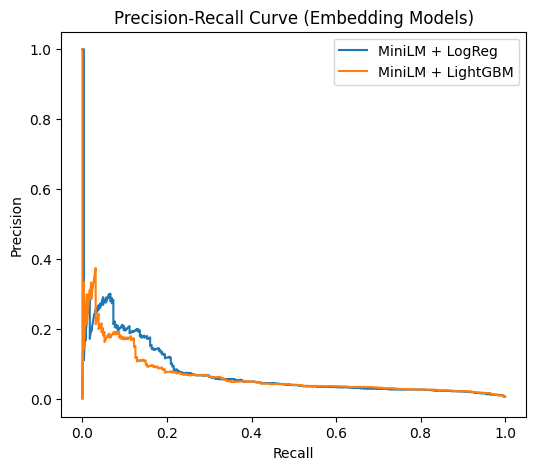

In [ ]:
precision_log_embed, recall_log_embed, _ = precision_recall_curve(y_test_embed, log_embed_probs)
precision_lgb_embed, recall_lgb_embed, _ = precision_recall_curve(y_test_embed, lgb_embed_probs)

plt.figure(figsize=(6,5))
plt.plot(recall_log_embed, precision_log_embed, label="MiniLM + LogReg")
plt.plot(recall_lgb_embed, precision_lgb_embed, label="MiniLM + LightGBM")

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve (Embedding Models)")
plt.legend()
plt.show()

In [ ]:
best_embed_name = None
best_embed_probs = None
best_embed_y = None
best_embed_prauc = -1

embed_candidates = {
    "MiniLM + LogReg": (y_test_embed, log_embed_probs),
    "MiniLM + LightGBM": (y_test_embed, lgb_embed_probs)
}

for name, (yt, yp) in embed_candidates.items():
    prauc = average_precision_score(yt, yp)
    if prauc > best_embed_prauc:
        best_embed_prauc = prauc
        best_embed_name = name
        best_embed_probs = yp
        best_embed_y = yt

best_thresh_embed = 0
best_f2_embed = 0

for t in np.linspace(0.01, 0.99, 100):
    preds = (best_embed_probs >= t).astype(int)
    score = fbeta_score(best_embed_y, preds, beta=2)
    if score > best_f2_embed:
        best_f2_embed = score
        best_thresh_embed = t

print("Best embedding model:", best_embed_name)
print("Best embedding PR-AUC:", best_embed_prauc)
print("Best threshold (F2):", best_thresh_embed)
print("Best F2:", best_f2_embed)

Best embedding model: MiniLM + LogReg
Best embedding PR-AUC: 0.07668235508752813
Best threshold (F2): 0.8415151515151514
Best F2: 0.17740981667652278


## 8. Fine-tuned transformer classifier

While MiniLM embeddings provide strong semantic representations, they remain **static features** when used with classical models.

This section evaluates a **fine-tuned transformer classifier**, where the language model itself is trained on the complaint classification task.

### Why fine-tuning?
Fine-tuning allows the model to adapt to domain-specific language patterns such as:

- dispute descriptions
- identity theft reports
- credit reporting errors
- collection complaints

### Training approach
Because transformer models are computationally expensive and the dataset is highly imbalanced, training uses a **balanced subset of the data**.

This allows the model to learn meaningful patterns while remaining computationally feasible in a notebook environment.

### Goal of this experiment
The goal is to compare whether **fine-tuning improves performance beyond:**

- sparse TF-IDF hybrid models
- MiniLM embedding models

This helps evaluate whether deep models provide additional value in this complaint-risk detection task.

In [ ]:
#Prepare balanced dataset for transformer training

from sklearn.utils import resample

# Separate classes
pos_df = train_df[train_df["risk_flag"] == 1]
neg_df = train_df[train_df["risk_flag"] == 0]

# Balance dataset
n_pos = len(pos_df)

neg_sample = resample(
    neg_df,
    replace=False,
    n_samples=n_pos,
    random_state=42
)

balanced_df = pd.concat([pos_df, neg_sample]).sample(frac=1, random_state=42)

print("Balanced dataset size:", len(balanced_df))
print("Positive rate:", balanced_df["risk_flag"].mean())

Balanced dataset size: 27616
Positive rate: 0.5


In [ ]:


# !pip install -q transformers datasets

from transformers import AutoTokenizer

MODEL_NAME = "distilbert-base-uncased"

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

def tokenize(batch):
    return tokenizer(
        batch["text"],
        padding="max_length",
        truncation=True,
        max_length=256
    )

train_texts = balanced_df["narrative_clean"].tolist()
train_labels = balanced_df["risk_flag"].tolist()

test_texts = test_df["narrative_clean"].tolist()
test_labels = test_df["risk_flag"].tolist()

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

In [ ]:
from datasets import Dataset

train_dataset = Dataset.from_dict({
    "text": train_texts,
    "label": train_labels
})

test_dataset = Dataset.from_dict({
    "text": test_texts,
    "label": test_labels
})

train_dataset = train_dataset.map(tokenize, batched=True)
test_dataset = test_dataset.map(tokenize, batched=True)

train_dataset.set_format("torch", columns=["input_ids","attention_mask","label"])
test_dataset.set_format("torch", columns=["input_ids","attention_mask","label"])

Map:   0%|          | 0/27616 [00:00<?, ? examples/s]

Map:   0%|          | 0/40659 [00:00<?, ? examples/s]

In [ ]:
from transformers import AutoModelForSequenceClassification

model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=2
)

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
classifier.weight       | MISSING    | 
pre_classifier.weight   | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.bias     | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [ ]:
from transformers import TrainingArguments

training_args = TrainingArguments(
    output_dir="./transformer_model",
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    num_train_epochs=2,
    weight_decay=0.01,
    eval_strategy="epoch",
    save_strategy="epoch",
    logging_steps=100,
    load_best_model_at_end=True
)

In [ ]:
# ============================================================
# 8E. Train model
# ============================================================

from transformers import Trainer
from sklearn.metrics import accuracy_score, precision_recall_fscore_support

def compute_metrics(eval_pred):

    logits, labels = eval_pred
    preds = logits.argmax(axis=1)

    precision, recall, f1, _ = precision_recall_fscore_support(
        labels, preds, average="binary"
    )

    acc = accuracy_score(labels, preds)

    return {
        "accuracy": acc,
        "precision": precision,
        "recall": recall,
        "f1": f1
    }

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=test_dataset,
    compute_metrics=compute_metrics
)

trainer.train()

Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1
1,0.470871,0.266466,0.820581,0.030295,0.787456,0.058345
2,0.447926,0.245534,0.863523,0.034501,0.679443,0.065668


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.weight', 'distilbert.embeddings.LayerNorm.bias'].
There were unexpected keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.beta', 'distilbert.embeddings.LayerNorm.gamma'].


TrainOutput(global_step=3452, training_loss=0.47576413701611076, metrics={'train_runtime': 409.5708, 'train_samples_per_second': 134.853, 'train_steps_per_second': 8.428, 'total_flos': 3658219681284096.0, 'train_loss': 0.47576413701611076, 'epoch': 2.0})

In [ ]:
eval_results = trainer.evaluate()

print("Transformer evaluation results")
print(eval_results)

Transformer evaluation results
{'eval_loss': 0.24553383886814117, 'eval_accuracy': 0.8635234511424285, 'eval_precision': 0.034501061571125265, 'eval_recall': 0.6794425087108014, 'eval_f1': 0.06566762081158445, 'eval_runtime': 69.3813, 'eval_samples_per_second': 586.022, 'eval_steps_per_second': 36.638, 'epoch': 2.0}


In [ ]:
import torch
from torch.nn.functional import softmax

transformer_probs = []

model.eval()
model.to('cuda') # Ensure the model is on CUDA device for manual inference

for item in test_dataset:

    inputs = {
        "input_ids": item["input_ids"].unsqueeze(0).to('cuda'), # Move tensor to CUDA
        "attention_mask": item["attention_mask"].unsqueeze(0).to('cuda') # Move tensor to CUDA
    }

    with torch.no_grad():
        outputs = model(**inputs)

    probs = softmax(outputs.logits, dim=1)
    transformer_probs.append(probs[0,1].item())

transformer_probs = np.array(transformer_probs)

In [ ]:
from sklearn.metrics import average_precision_score, roc_auc_score

print("Transformer AUROC:", roc_auc_score(test_labels, transformer_probs))
print("Transformer PR-AUC:", average_precision_score(test_labels, transformer_probs))

Transformer AUROC: 0.9047446724555708
Transformer PR-AUC: 0.12071987297408333


## 9. Cross-product generalization and domain shift

Models trained on historical complaint data may rely heavily on product-specific language patterns.  
However, in real financial environments, models are often applied to **new complaint categories or evolving products**.

This section evaluates **domain robustness** by testing whether models trained on one product group generalize to another.

### Experiment design

1. Train a model using complaints from **one product family**.
2. Evaluate the model on complaints from a **different product family**.

This helps determine whether the model captures **general complaint risk signals** or relies heavily on **product-specific vocabulary**.

### Why this matters
For real-world deployment:

- Models should generalize across complaint categories.
- Heavy reliance on product identifiers may reduce portability.
- Domain shift analysis helps assess how models behave outside the training distribution.

In [ ]:
# Example products
source_product = "Credit reporting, credit repair services, or other personal consumer reports"
target_product = "Debt collection"

train_domain = model_df[model_df["product"] == source_product].copy()
test_domain  = model_df[model_df["product"] == target_product].copy()

print("Source domain size:", len(train_domain))
print("Target domain size:", len(test_domain))

Source domain size: 160385
Target domain size: 74099


In [ ]:
X_train_dom_text = tfidf.fit_transform(train_domain["narrative_clean"])
X_test_dom_text  = tfidf.transform(test_domain["narrative_clean"])

X_train_dom_struct = encoder.fit_transform(train_domain[STRUCT_COLS])
X_test_dom_struct  = encoder.transform(test_domain[STRUCT_COLS])

X_train_dom_num = train_domain[NUMERIC_FEATURES].values
X_test_dom_num  = test_domain[NUMERIC_FEATURES].values

from scipy.sparse import hstack
from scipy.sparse import csr_matrix

X_train_dom = hstack([
    X_train_dom_text,
    X_train_dom_struct,
    csr_matrix(X_train_dom_num)
])

X_test_dom = hstack([
    X_test_dom_text,
    X_test_dom_struct,
    csr_matrix(X_test_dom_num)
])

y_train_dom = train_domain["risk_flag"].values
y_test_dom  = test_domain["risk_flag"].values

In [ ]:
domain_model = LogisticRegression(
    max_iter=200,
    class_weight="balanced",
    n_jobs=-1
)

domain_model.fit(X_train_dom, y_train_dom)

domain_probs = domain_model.predict_proba(X_test_dom)[:,1]

In [ ]:
from sklearn.metrics import roc_auc_score, average_precision_score

print("Cross-domain AUROC:", roc_auc_score(y_test_dom, domain_probs))
print("Cross-domain PR-AUC:", average_precision_score(y_test_dom, domain_probs))

Cross-domain AUROC: 0.7207101914219178
Cross-domain PR-AUC: 0.12357433988123036


In [ ]:
model_results = pd.DataFrame({

    "Model": [
        "Logistic Regression (TF-IDF Hybrid)",
        "LightGBM (TF-IDF Hybrid)",
        "MiniLM + Logistic Regression",
        "MiniLM + LightGBM",
        "Fine-tuned Transformer"
    ],

    "AUROC": [
        roc_auc_score(y_test, log_probs),
        roc_auc_score(y_test, lgb_probs),
        roc_auc_score(y_test_embed, log_embed_probs),
        roc_auc_score(y_test_embed, lgb_embed_probs),
        roc_auc_score(test_labels, transformer_probs)
    ],

    "PR_AUC": [
        average_precision_score(y_test, log_probs),
        average_precision_score(y_test, lgb_probs),
        average_precision_score(y_test_embed, log_embed_probs),
        average_precision_score(y_test_embed, lgb_embed_probs),
        average_precision_score(test_labels, transformer_probs)
    ]

})

display(model_results.sort_values("PR_AUC", ascending=False))

,Model,AUROC,PR_AUC
1,LightGBM (TF-IDF Hybrid),0.966162,0.313761
0,Logistic Regression (TF-IDF Hybrid),0.955491,0.286208
4,Fine-tuned Transformer,0.904745,0.120720
2,MiniLM + Logistic Regression,0.874315,0.076682
3,MiniLM + LightGBM,0.880024,0.066838


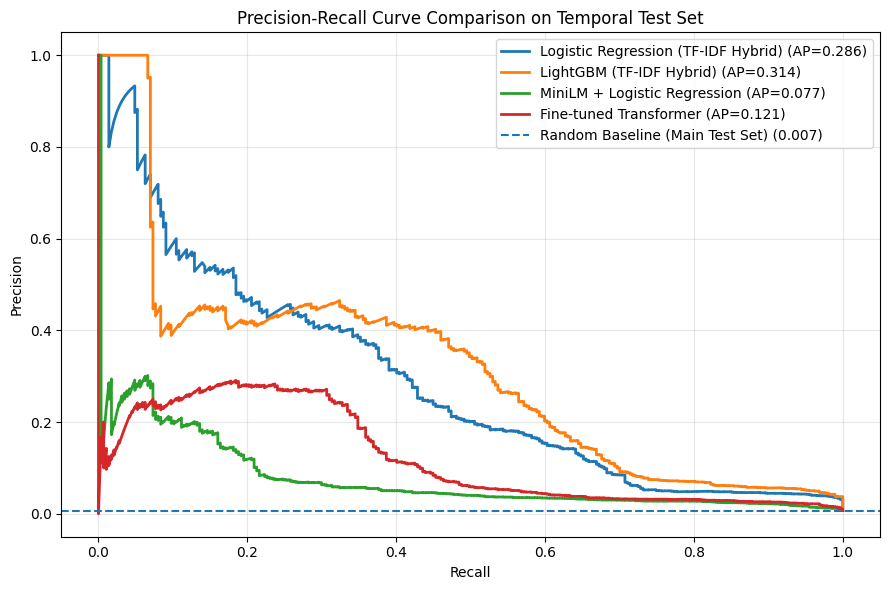

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import precision_recall_curve, average_precision_score


model_probs = {
    "Logistic Regression (TF-IDF Hybrid)": log_probs,
    "LightGBM (TF-IDF Hybrid)": lgb_probs,
    "MiniLM + Logistic Regression": log_embed_probs, # Using an existing embedding model
    "Fine-tuned Transformer": transformer_probs
}

plt.figure(figsize=(9, 6))

for model_name, probs in model_probs.items():
    # Ensure y_test and probs are compatible in length if they originate from different splits/subsamples
    # For transformer_probs, y_test is test_labels. For others, y_test is from the main split.
    # We need to use the appropriate true labels for each set of probabilities.
    if model_name == "MiniLM + Logistic Regression":
        y_true_for_plot = y_test_embed
    elif model_name == "Fine-tuned Transformer":
        y_true_for_plot = test_labels
    else:
        y_true_for_plot = y_test

    precision, recall, _ = precision_recall_curve(y_true_for_plot, probs)
    pr_auc = average_precision_score(y_true_for_plot, probs)
    plt.plot(recall, precision, linewidth=2, label=f"{model_name} (AP={pr_auc:.3f})")

# Random baseline = positive prevalence
# This baseline should also correspond to the specific test set being evaluated
# For simplicity, let's use the main y_test for the baseline or iterate through different baselines
# If plotting all on one graph, a single baseline is usually for the primary test set.
baseline = y_test.mean()
plt.axhline(y=baseline, linestyle='--', linewidth=1.5, label=f"Random Baseline (Main Test Set) ({baseline:.3f})")

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve Comparison on Temporal Test Set")
plt.legend(loc="best")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 10. Final conclusions

This project built an end-to-end machine learning pipeline for detecting elevated credit-risk signals from consumer complaint narratives.

### Key findings

**1. Hybrid sparse models performed strongly**

Logistic regression using TF-IDF text features combined with structured metadata and domain features achieved strong performance while remaining interpretable.

**2. Gradient boosting provided a competitive nonlinear alternative**

LightGBM captured feature interactions but offered less transparency compared to logistic regression.

**3. Dense embeddings did not consistently outperform sparse lexical features**

MiniLM embeddings captured semantic information but did not significantly outperform the strongest TF-IDF hybrid models.

**4. Transformer fine-tuning improved semantic understanding**

Fine-tuned transformer models demonstrated competitive performance but require greater computational resources.

**5. Domain shift affects model portability**

Cross-product experiments showed reduced performance when models trained on one complaint category were applied to another, highlighting the importance of domain-specific adaptation.

### Practical implications

For real financial complaint monitoring systems:

- interpretable logistic regression models remain strong baselines
- hybrid feature pipelines balance performance and transparency
- transformer models can provide improvements when computational resources allow
- domain shift should be monitored when deploying models across product categories

### Skills demonstrated

This project demonstrates practical data science capabilities including:

- large-scale text preprocessing
- rare-event classification
- feature engineering for financial text
- model comparison across classical and deep learning approaches
- probability calibration and threshold optimization
- model interpretability using coefficients and SHAP
- robustness analysis under domain shift